In [ ]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2

from grsc_cb.model import GRSC_CB_Model
from grsc_cb.instance import GRSC_CB_Instance
import numpy as np
from scipy.spatial import Delaunay, ConvexHull
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# number of land parcels
n = 400
# number of species
m = 20
# number of max connected areas
k = 2
# range of habitat suitability function
w_min, w_max = 20, 100
# range of costs
c_min, c_max = 1, 100
# lambda percentage threshold
lambda_threshold = 0.05
# buffer size
d = 1
# tau threshold
tau = 0.8

External nodes: {np.int32(226), np.int32(324), np.int32(261), np.int32(327), np.int32(231), np.int32(394), np.int32(234), np.int32(266), np.int32(298), np.int32(107), np.int32(79), np.int32(304), np.int32(215), np.int32(120), np.int32(159)}


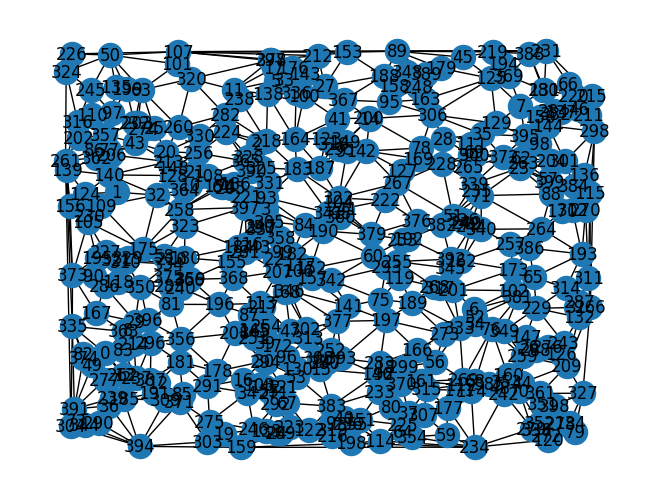

In [15]:
# generate a random instance Delunay graph
points = np.random.rand(n, 2)
tri = Delaunay(points)

G = nx.Graph()
G.add_nodes_from(range(len(points)))

# for each node, it connects it to its neighbors using Delaunay triangulation
for simplex in tri.simplices:
    i, j, h = simplex
    G.add_edge(i, j)
    G.add_edge(j, h)
    G.add_edge(i, h)

# determines the set of external nodes  
external_nodes = set(ConvexHull(points).vertices)
nx.draw(G, points, with_labels=True)
print(f"External nodes: {external_nodes}")

In [16]:
# costs of land parcels
c = {i: np.random.randint(c_min, c_max + 1) for i in G.nodes}

In [17]:
# specie definition
S_1 = list(range(m//3))
S_2 = list(range(m//3, m))
P_1 = len(S_1)
P_2 = len(S_2)

# habitat suitability score function
w = {}
for s in S_1 + S_2:
    prob_zero = 0.2 if s in S_1 else 0.1
    for i in G.nodes:
        if i in external_nodes and s in S_1:
            w[(i, s)] = 0
        elif np.random.rand() < prob_zero:
            w[(i, s)] = 0
        else:
            w[(i, s)] = np.random.randint(w_min, w_max + 1)
            
# suitability quota
lambda_s = {s: lambda_threshold * sum(w[(i, s)] for i in G.nodes) for s in S_1 + S_2}

In [18]:
# toy instance
V, E = set(G.nodes), set(G.edges)
instance = GRSC_CB_Instance(V, E, points, 
                            S_1, S_2, P_1, P_2, 
                            k, w, lambda_s, c, tau, d)

instance.draw_graph()


GRSC_CB_Instance(|V|=400, |E|=1182, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 69.0
Nodes in the reserve (x): [13, 16, 48, 71, 72, 76, 80, 85, 94, 103, 123, 132, 134, 196, 202, 206, 233, 238, 258, 305, 364]
Nodes in the core (z): [13, 16, 48, 71, 72, 76, 80, 85, 94, 103, 123, 132, 134, 196, 202, 206, 233, 238, 258, 305, 364]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
r-arc-node separators (y): []


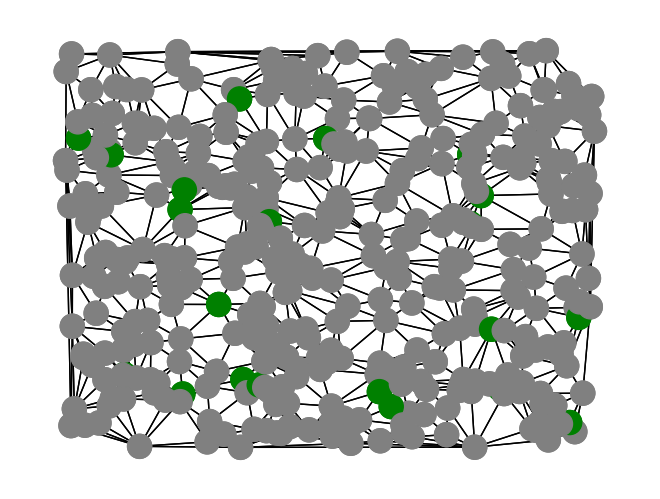

In [ ]:
print(instance)
model = GRSC_CB_Model(instance, B=False, C=False)
model.solve()
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1182, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 1226.0
Nodes in the reserve (x): [7, 46, 66, 90, 98, 105, 109, 118, 131, 137, 144, 150, 156, 175, 195, 211, 215, 220, 227, 230, 231, 280, 284, 286, 298, 301, 310, 321, 329, 332, 334, 350, 369, 373, 388, 395]
Nodes in the core (z): [46, 66, 90, 105, 118, 131, 137, 144, 150, 195, 211, 220, 227, 280, 284, 310, 321, 329, 332]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
r-arc-node separators (y): []


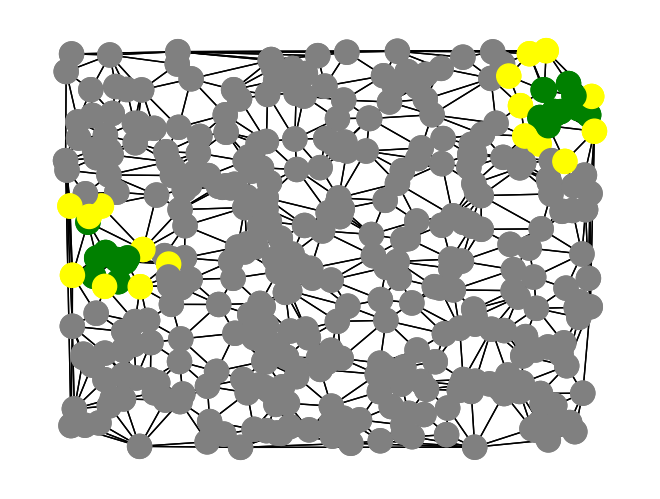

In [ ]:
print(instance)
model = GRSC_CB_Model(instance, C=False)
model.solve()
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1182, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 292, 'corecon-frc': 0, 'cover-s1': 495, 'cover-s2': 767, 'scc': 0}
Status: 2 Optimal
Objective: 340.0
Nodes in the reserve (x): [10, 21, 32, 37, 80, 92, 105, 109, 140, 148, 175, 206, 233, 256, 258, 299, 315, 323, 330, 334, 364, 397]
Nodes in the core (z): [10, 21, 32, 37, 80, 92, 105, 109, 140, 148, 175, 206, 233, 256, 258, 299, 315, 323, 330, 334, 364]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
r-arc-node separators (y): [10, 37]


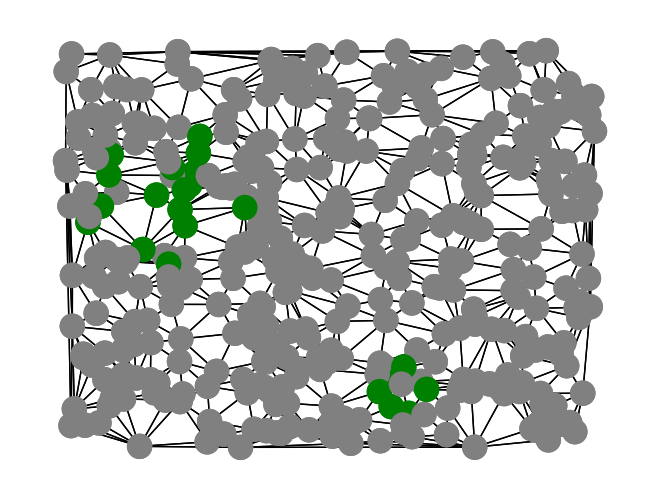

In [ ]:
print(instance)
model = GRSC_CB_Model(instance, B=False)
model.solve()
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1182, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 113, 'corecon-frc': 0, 'cover-s1': 98, 'cover-s2': 0, 'scc': 0}
Status: 2 Optimal
Objective: 1312.0
Nodes in the reserve (x): [3, 22, 32, 58, 84, 90, 99, 105, 109, 116, 118, 175, 180, 182, 184, 195, 210, 227, 250, 258, 281, 286, 305, 310, 321, 323, 329, 334, 337, 343, 347, 350, 358, 373, 397]
Nodes in the core (z): [58, 90, 99, 116, 118, 175, 195, 210, 227, 250, 305, 310, 321, 323, 329, 337, 343, 347, 358]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
r-arc-node separators (y): [90, 99]


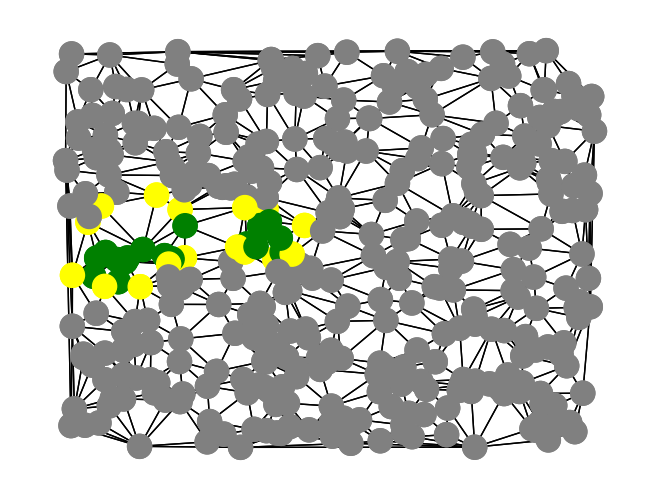

In [ ]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve()
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1182, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
	 * Starting construction heuristic...
	 * Initial solution found with Construction Heuristic. Nodes: {0, 1, 2, 3, 4, 11, 13, 32, 42, 49, 50, 51, 63, 71, 82, 83, 84, 86, 91, 93, 101, 104, 105, 107, 109, 124, 127, 135, 138, 139, 140, 156, 164, 167, 183, 187, 199, 202, 218, 221, 222, 224, 226, 228, 230, 235, 238, 241, 244, 245, 249, 260, 261, 262, 267, 282, 297, 304, 305, 316, 320, 322, 324, 325, 326, 328, 330, 331, 335, 339, 341, 347, 362, 363, 373, 374, 376, 382, 391, 397}
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 154, 'corecon-frc': 0, 'cover-s1': 97, 'cover-s2': 0, 'scc': 0}
Status: 2 Optimal
Objective: 1304.0
Nodes in the reserve (x): [7, 46, 62, 66, 90, 98, 105, 109, 118, 131, 137, 144, 150, 156, 175, 195, 204, 211, 215, 220, 227, 230, 231, 280, 284, 286, 298, 301, 310, 321, 329, 332, 334, 350, 369, 373, 388, 395]
Nodes in the core (z

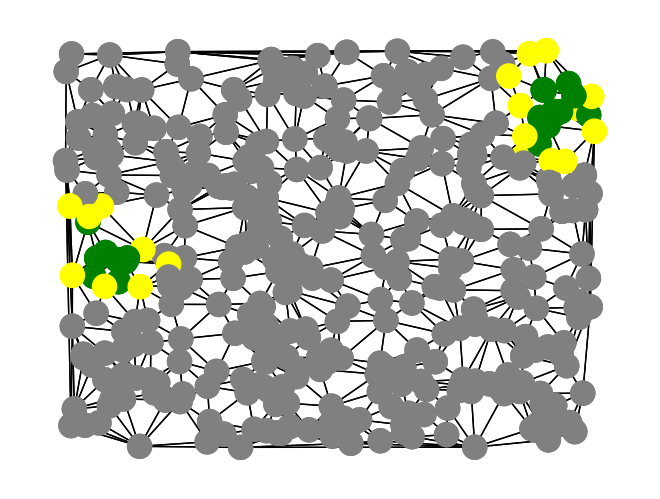

In [ ]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve(cp_heuristic=True)
model.print_solution()

GRSC_CB_Instance(|V|=400, |E|=1182, |S1|=6, |S2|=14, P1=6, P2=14, k=2, d=1)
Set parameter LazyConstraints to value 1
	 * Starting construction heuristic...
	 * Initial solution found with Construction Heuristic. Nodes: {0, 1, 2, 3, 4, 13, 20, 21, 32, 42, 43, 49, 51, 71, 82, 83, 84, 90, 91, 93, 104, 105, 108, 109, 124, 127, 128, 138, 139, 140, 148, 156, 164, 167, 175, 183, 187, 195, 206, 213, 218, 221, 222, 224, 227, 228, 230, 235, 238, 241, 244, 249, 250, 256, 261, 262, 267, 282, 286, 304, 305, 322, 325, 326, 328, 330, 331, 335, 337, 339, 341, 347, 362, 363, 365, 373, 374, 376, 382, 391, 397}
	 * Starting local branching heuristic...
	 * Added constraints: {'corecon-int': 22, 'corecon-frc': 0, 'cover-s1': 1, 'cover-s2': 0, 'scc': 0}
	 * Added constraints: {'corecon-int': 1, 'corecon-frc': 0, 'cover-s1': 1, 'cover-s2': 0, 'scc': 0}
	 * Added constraints: {'corecon-int': 12, 'corecon-frc': 0, 'cover-s1': 58, 'cover-s2': 0, 'scc': 0}
	 * Added constraints: {'corecon-int': 0, 'corecon-frc'

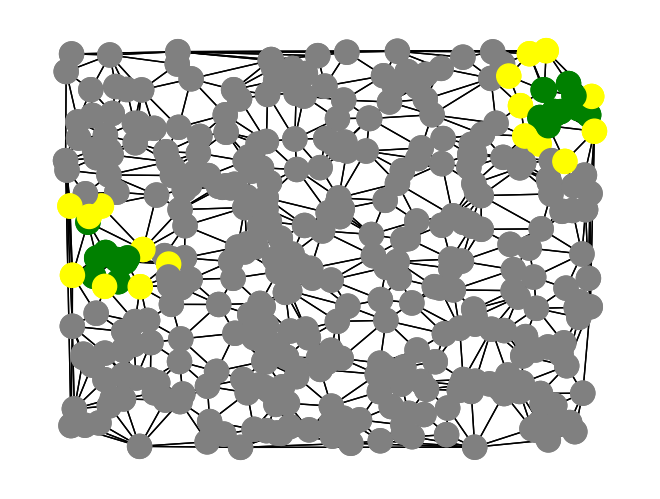

In [ ]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve(cp_heuristic=True, lb_heuristic=True)
model.print_solution()